# Exploratory Data Analysis — PRDECT-ID

**Tujuan**: Memahami karakteristik dataset ulasan Tokopedia sebelum pemodelan.

Analisis meliputi distribusi kelas, statistik teks, kata khas per emosi, hubungan rating dengan emosi, dan korelasi sentimen-emosi.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

RANDOM_STATE = 42

In [2]:
df_path = Path("../data/raw/ecommerce_reviews.csv")

if not os.path.exists(df_path):
    df = pd.read_csv("https://prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com/59cda965-7204-45c5-b4ca-29dc27392cf7")
    df_path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(df_path, index=False)
else:
    df = pd.read_csv(df_path)

df.head(3)

,Category,Product Name,Location,Price,Overall Rating,Number Sold,Total Review,Customer Rating,Customer Review,Sentiment,Emotion
0,Computers and Laptops,Wireless Keyboard i8 Mini TouchPad Mouse 2.4G ...,Jakarta Utara,53500,4.9,5449,2369,5,Alhamdulillah berfungsi dengan baik. Packaging...,Positive,Happy
1,Computers and Laptops,PAKET LISENSI WINDOWS 10 PRO DAN OFFICE 2019 O...,Kota Tangerang Selatan,72000,4.9,2359,1044,5,"barang bagus dan respon cepat, harga bersaing ...",Positive,Happy
2,Computers and Laptops,SSD Midasforce 128 Gb - Tanpa Caddy,Jakarta Barat,213000,5.0,12300,3573,5,"barang bagus, berfungsi dengan baik, seler ram...",Positive,Happy


## 1. Informasi Dasar Dataset

In [3]:
print(f"Shape: {df.shape}")
print(f"\nKolom: {list(df.columns)}")
print(f"\nTipe data:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")

Shape: (5400, 11)

Kolom: ['Category', 'Product Name', 'Location', 'Price', 'Overall Rating', 'Number Sold', 'Total Review', 'Customer Rating', 'Customer Review', 'Sentiment', 'Emotion']

Tipe data:
Category               str
Product Name           str
Location               str
Price                int64
Overall Rating     float64
Number Sold          int64
Total Review         int64
Customer Rating      int64
Customer Review        str
Sentiment              str
Emotion                str
dtype: object

Missing values:
Category           0
Product Name       0
Location           0
Price              0
Overall Rating     0
Number Sold        0
Total Review       0
Customer Rating    0
Customer Review    0
Sentiment          0
Emotion            0
dtype: int64


In [4]:
print("=== Distribusi Sentimen ===")
print(df['Sentiment'].value_counts())
print(f"\n=== Distribusi Emosi ===")
print(df['Emotion'].value_counts())
print(f"\n=== Persentase Emosi ===")
print(df['Emotion'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

=== Distribusi Sentimen ===
Sentiment
Negative    2821
Positive    2579
Name: count, dtype: int64

=== Distribusi Emosi ===
Emotion
Happy      1770
Sadness    1202
Fear        920
Love        809
Anger       699
Name: count, dtype: int64

=== Persentase Emosi ===
Emotion
Happy      32.8%
Sadness    22.3%
Fear       17.0%
Love       15.0%
Anger      12.9%
Name: proportion, dtype: str


## 2. Sentimen vs Emosi

In [5]:
ct = pd.crosstab(df['Emotion'], df['Sentiment'])
print(ct)
print(f"\n=== Proporsi Sentimen per Emosi ===")
print(ct.div(ct.sum(axis=1), axis=0).mul(100).round(1).astype(str) + '%')

Sentiment  Negative  Positive
Emotion                      
Anger           699         0
Fear            920         0
Happy             0      1770
Love              0       809
Sadness        1202         0

=== Proporsi Sentimen per Emosi ===
Sentiment Negative Positive
Emotion                    
Anger       100.0%     0.0%
Fear        100.0%     0.0%
Happy         0.0%   100.0%
Love          0.0%   100.0%
Sadness     100.0%     0.0%


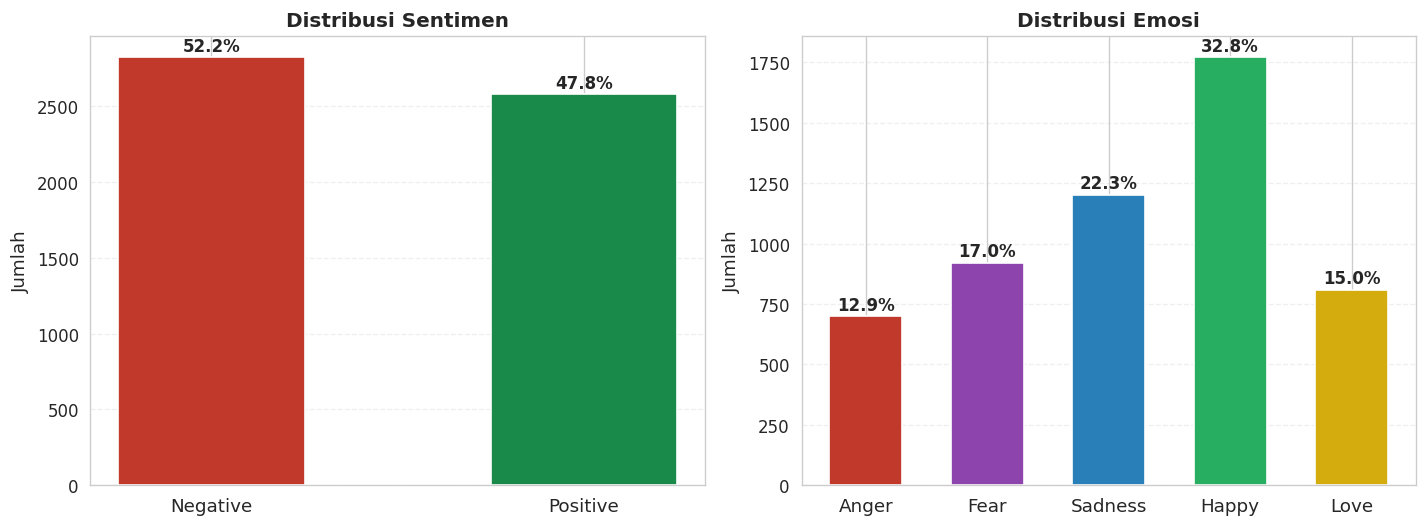

In [6]:
plt.rcParams['font.family'] = 'sans-serif'

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
total = len(df)

# --- Chart kiri: Sentimen ---
sent_colors = ['#c0392b', '#1a8a4a']
sent_counts = df['Sentiment'].value_counts()
bars1 = ax1.bar(sent_counts.index, sent_counts.values, color=sent_colors, width=0.5)
ax1.set_title('Distribusi Sentimen', fontsize=12, fontweight='bold')
ax1.set_ylabel('Jumlah', fontsize=11)
ax1.tick_params(axis='x', rotation=0, labelsize=11)
ax1.tick_params(axis='y', labelsize=10)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.set_axisbelow(True)
for bar in bars1:
    pct = bar.get_height() / total * 100
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 15,
             f'{pct:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# --- Chart kanan: Emosi ---
emotion_order = ['Anger', 'Fear', 'Sadness', 'Happy', 'Love']
emo_colors = ['#c0392b', '#8e44ad', '#2980b9', '#27ae60', '#d4ac0d']
emo_counts = df['Emotion'].value_counts()
bars2 = ax2.bar(emotion_order, [emo_counts[e] for e in emotion_order], color=emo_colors, width=0.6)
ax2.set_title('Distribusi Emosi', fontsize=12, fontweight='bold')
ax2.set_ylabel('Jumlah', fontsize=11)
ax2.tick_params(axis='x', rotation=0, labelsize=11)
ax2.tick_params(axis='y', labelsize=10)
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.set_axisbelow(True)
for bar in bars2:
    pct = bar.get_height() / total * 100
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
             f'{pct:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

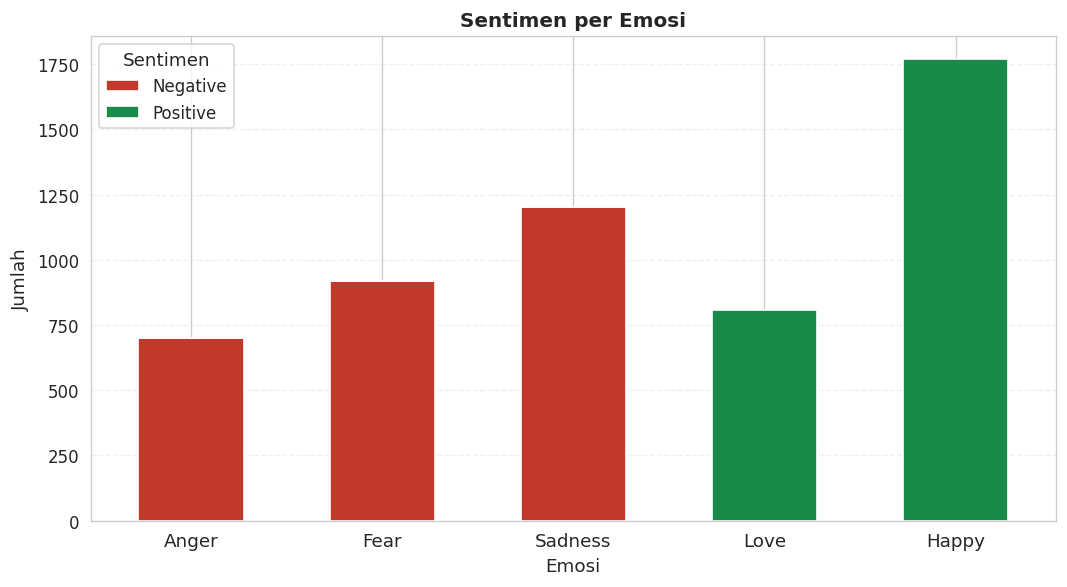

In [11]:
plt.rcParams['font.family'] = 'sans-serif'

emo_order_stacked = ['Anger', 'Fear', 'Sadness', 'Love', 'Happy']
ct_stacked = df.groupby(['Emotion', 'Sentiment']).size().unstack(fill_value=0)
ct_stacked = ct_stacked.reindex(emo_order_stacked)

ax = ct_stacked.plot(
    kind='bar', stacked=True, figsize=(9, 5),
    color=['#c0392b', '#1a8a4a'], width=0.55, ax=None
)
ax.set_title('Sentimen per Emosi', fontsize=12, fontweight='bold')
ax.set_ylabel('Jumlah', fontsize=11)
ax.set_xlabel('Emosi', fontsize=11)
ax.tick_params(axis='x', rotation=0, labelsize=11)
ax.tick_params(axis='y', labelsize=10)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
ax.legend(title='Sentimen', fontsize=10, title_fontsize=11)

plt.tight_layout()
plt.show()

## 3. Statistik Panjang Teks per Emosi

In [8]:
df['review_length'] = df['Customer Review'].fillna('').apply(len)
df['word_count'] = df['Customer Review'].fillna('').apply(lambda x: len(x.split()))

print("=== Rata-rata Panjang Teks per Emosi ===")
stats = df.groupby('Emotion')[['review_length', 'word_count']].describe().round(1)
print(stats)

=== Rata-rata Panjang Teks per Emosi ===
        review_length                                                \
                count   mean    std  min   25%   50%    75%     max   
Emotion                                                               
Anger           699.0  111.8  115.6  5.0  42.0  76.0  136.0  1058.0   
Fear            920.0  137.3  131.9  4.0  53.0  99.0  172.0  1038.0   
Happy          1770.0   84.8   67.1  4.0  42.0  69.0  109.0   990.0   
Love            809.0   96.3   82.8  3.0  46.0  80.0  120.0  1046.0   
Sadness        1202.0  106.6   97.9  6.0  43.0  78.5  135.0   872.0   

        word_count                                           
             count  mean   std  min  25%   50%   75%    max  
Emotion                                                      
Anger        699.0  18.0  18.6  1.0  6.0  12.0  22.0  184.0  
Fear         920.0  22.0  21.0  1.0  8.0  15.0  27.0  155.0  
Happy       1770.0  12.5  10.0  1.0  6.0  10.0  16.0  130.0  
Love         809.0

NameError: name 'colors' is not defined

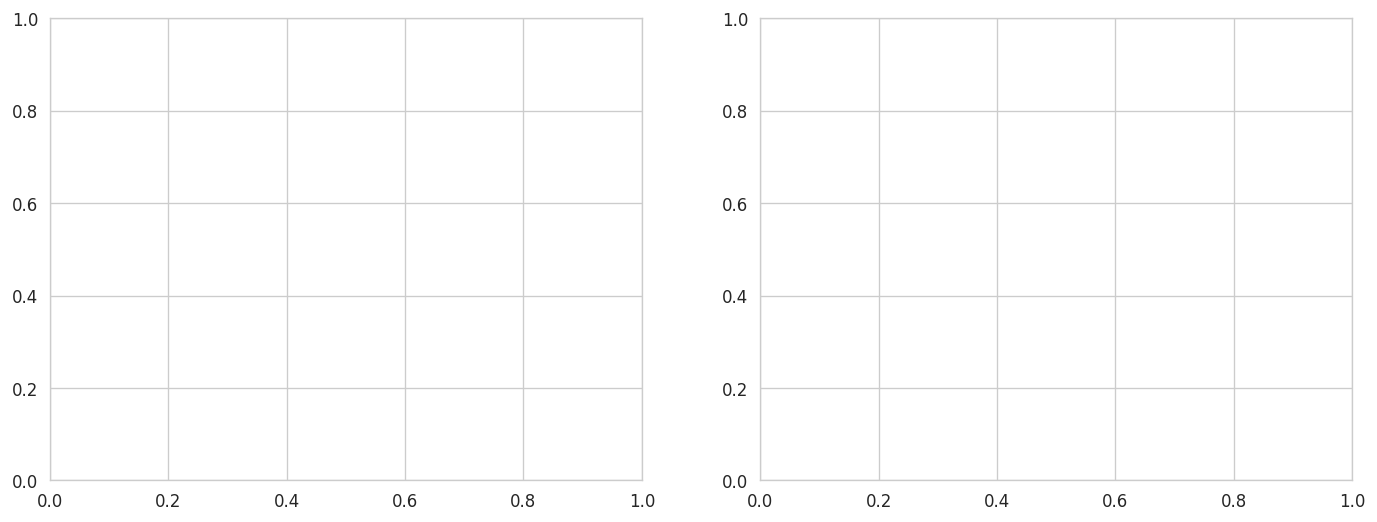

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

emotion_order = ['Happy', 'Love', 'Sadness', 'Fear', 'Anger']
palette = [colors[e] for e in emotion_order]

sns.boxplot(data=df, x='Emotion', y='review_length', order=emotion_order, palette=palette, ax=ax1)
ax1.set_title('Distribusi Panjang Teks (karakter) per Emosi')
ax1.set_ylabel('Jumlah Karakter')

sns.boxplot(data=df, x='Emotion', y='word_count', order=emotion_order, palette=palette, ax=ax2)
ax2.set_title('Distribusi Jumlah Kata per Emosi')
ax2.set_ylabel('Jumlah Kata')

plt.tight_layout()
plt.show()

## 4. Rating Pelanggan per Emosi

In [ ]:
print("=== Rata-rata Rating per Emosi ===")
print(df.groupby('Emotion')['Customer Rating'].describe().round(2))

=== Rata-rata Rating per Emosi ===
          count  mean   std  min  25%  50%  75%  max
Emotion                                             
Anger     699.0  1.26  0.61  1.0  1.0  1.0  1.0  5.0
Fear      920.0  1.51  0.74  1.0  1.0  1.0  2.0  4.0
Happy    1770.0  4.74  0.50  3.0  5.0  5.0  5.0  5.0
Love      809.0  4.96  0.21  3.0  5.0  5.0  5.0  5.0
Sadness  1202.0  1.67  0.84  1.0  1.0  1.0  2.0  5.0


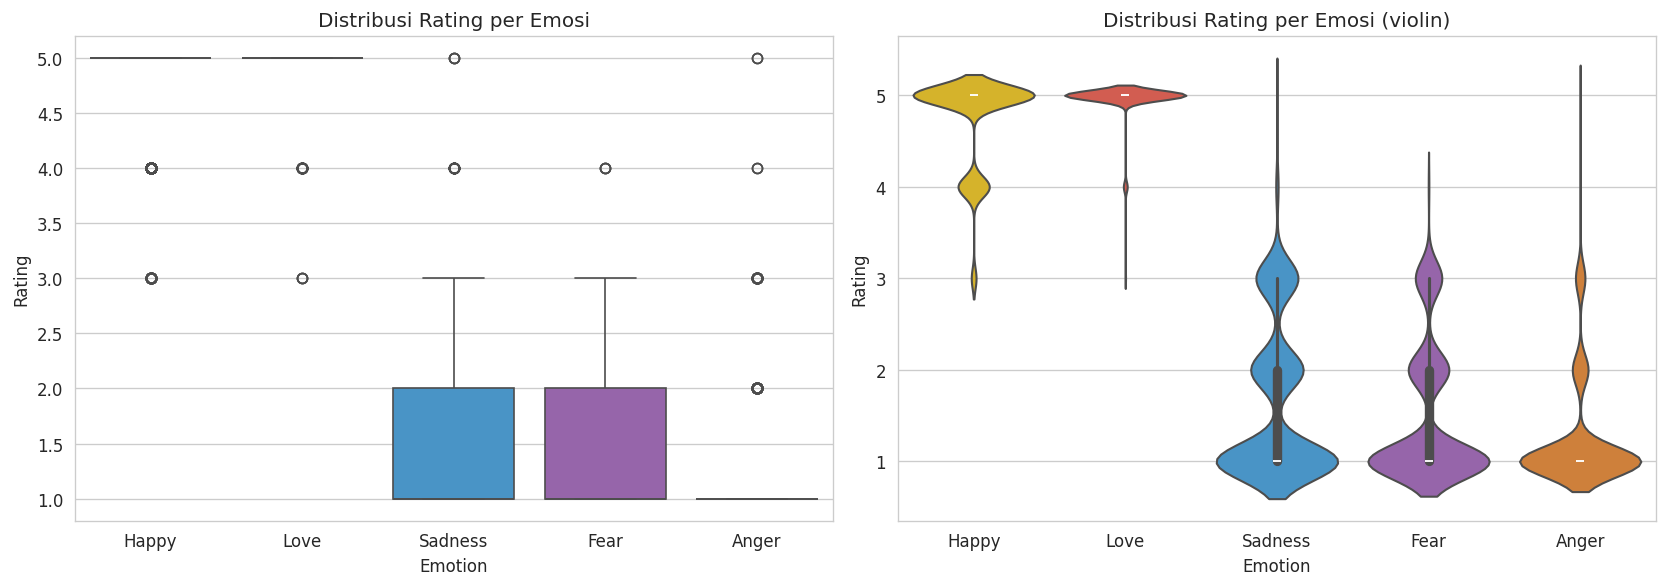

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='Emotion', y='Customer Rating', order=emotion_order, palette=palette, ax=axes[0])
axes[0].set_title('Distribusi Rating per Emosi')
axes[0].set_ylabel('Rating')

sns.violinplot(data=df, x='Emotion', y='Customer Rating', order=emotion_order, palette=palette, ax=axes[1])
axes[1].set_title('Distribusi Rating per Emosi (violin)')
axes[1].set_ylabel('Rating')

plt.tight_layout()
plt.show()

## 5. Kata Paling Sering per Emosi

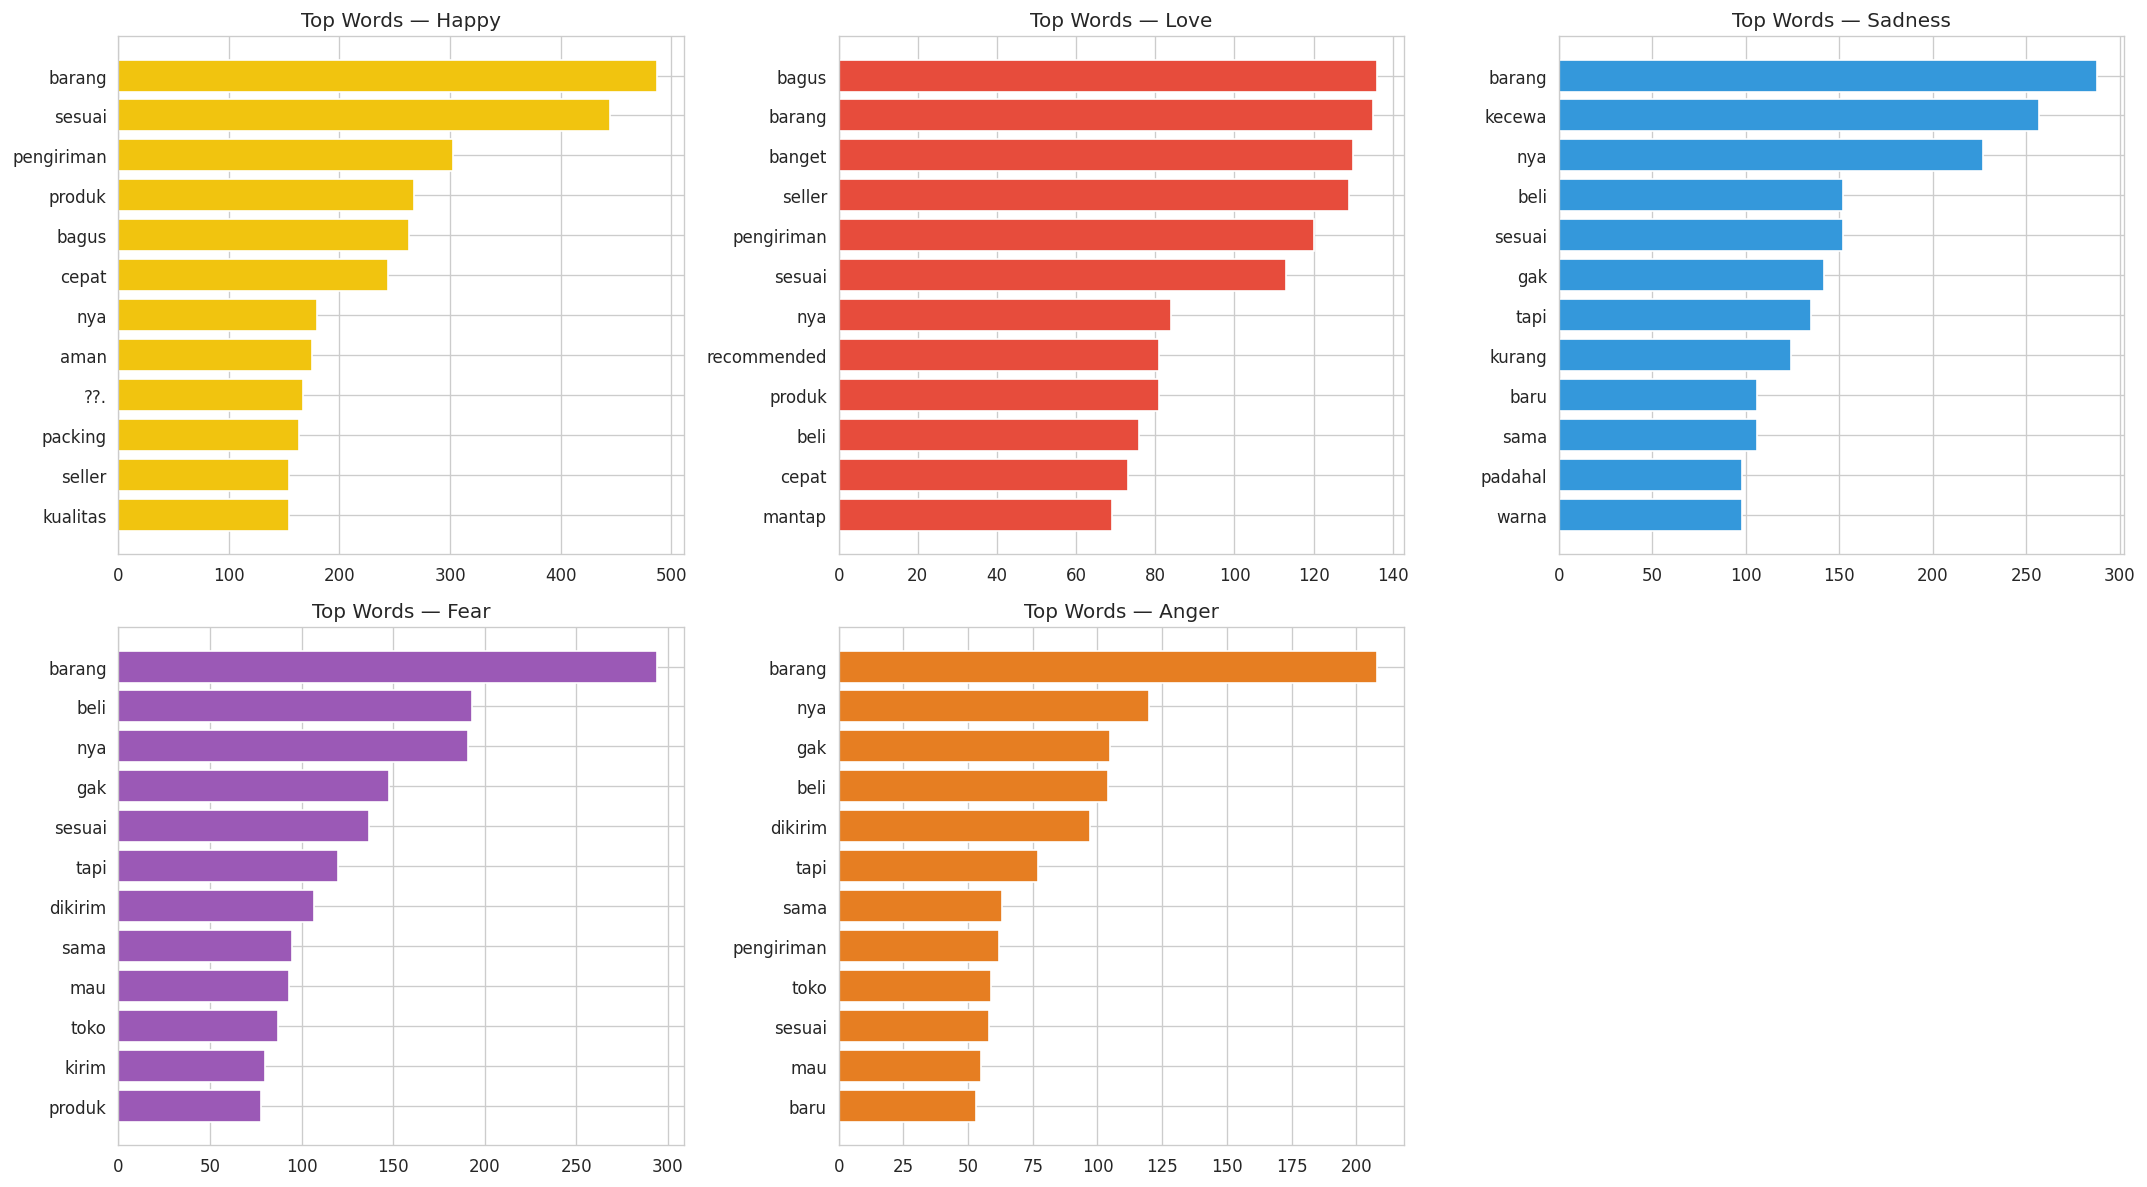

In [ ]:
def top_words(series, n=15):
    words = ' '.join(series.fillna('').str.lower()).split()
    stop_words = set(['dan', 'di', 'ke', 'dari', 'yang', 'ini', 'itu', 'dengan',
                      'untuk', 'pada', 'adalah', 'dalam', 'akan', 'telah',
                      'sudah', 'bisa', 'dapat', 'saya', 'aku', 'kami', 'kita',
                      'tidak', 'juga', 'sangat', 'ada', 'oleh', 'atau', 'saat',
                      'karena', 'seperti', 'setelah', 'antara', 'tanpa'])
    words = [w for w in words if w not in stop_words and len(w) > 2]
    return Counter(words).most_common(n)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, emotion in enumerate(emotion_order):
    subset = df[df['Emotion'] == emotion]['Customer Review']
    top = top_words(subset, 12)
    words, counts = zip(*top)
    axes[i].barh(range(len(words)), counts, color=colors[emotion])
    axes[i].set_yticks(range(len(words)))
    axes[i].set_yticklabels(words)
    axes[i].invert_yaxis()
    axes[i].set_title(f'Top Words — {emotion}')

axes[5].axis('off')
plt.tight_layout()
plt.show()

## 6. Contoh Ulasan per Emosi

In [ ]:
for emotion in emotion_order:
    print(f"\n{'='*60}")
    print(f"  {emotion.upper()}")
    print(f"{'='*60}")
    samples = df[df['Emotion'] == emotion]['Customer Review'].sample(5, random_state=RANDOM_STATE).values
    for j, s in enumerate(samples, 1):
        print(f"  {j}. {s[:120]}{'...' if len(str(s)) > 120 else ''}")


  HAPPY
  1. Barang sudah di trima dgn baik dan rapi, suara nya oke... Thanks
  2. Respon pengiriman cepat, produk ori dan expired masih lama. Semoga berhasil mengatasi rambut rontok dan tipis. Awet juga...
  3. Produk original ??
  4. barang sesuai, thank you
  5. Produk sesuai deskripsi penjual. Penjual komunikatif dan cekatan. Semoga tidak ada kendala saat pemakaian. Thanks seller...

  LOVE
  1. mantap hijabnyaaa, enaaaaaak dipakai, adeeeeem
  2. Pakai Lem ini hati�. Pastikan penataannya balon sebelum dipasang, kalau nda ga bisa dicabut. bisa dicabut tp resiko peca...
  3. Produk top markotop bangeet deh, selalu ada promo, ikan sehat dan cantik cantik dan delivery cepat sekali dan seller rec...
  4. mantul bet??????
  5. Thanks atas respon nya. Informasi yg diberikan jelas, product nya oke bgt. Uda 2x order kesini. Barang yg di kirim rapi ...

  SADNESS
  1. Produk yang saya terima kondisi motor sabliziernya kurang baik, al hasil video bukannya jadi mulus malah unstableized
  2. u

## 7. Kategori Produk

In [ ]:
print("=== Distribusi Kategori Produk ===")
print(df['Category'].value_counts().head(15))
print(f"\nTotal kategori unik: {df['Category'].nunique()}")

=== Distribusi Kategori Produk ===
Category
Computers and Laptops       200
Toys and Hobbies            200
Food and Drink              200
Office & Stationery         200
Automotive                  200
Animal Care                 200
Body Care                   200
Party Supplies and Craft    200
Carpentry                   200
Other Products              200
Sport                       200
Books                       200
Kitchen                     200
Electronics                 200
Kids and Baby Fashion       200
Name: count, dtype: int64

Total kategori unik: 29


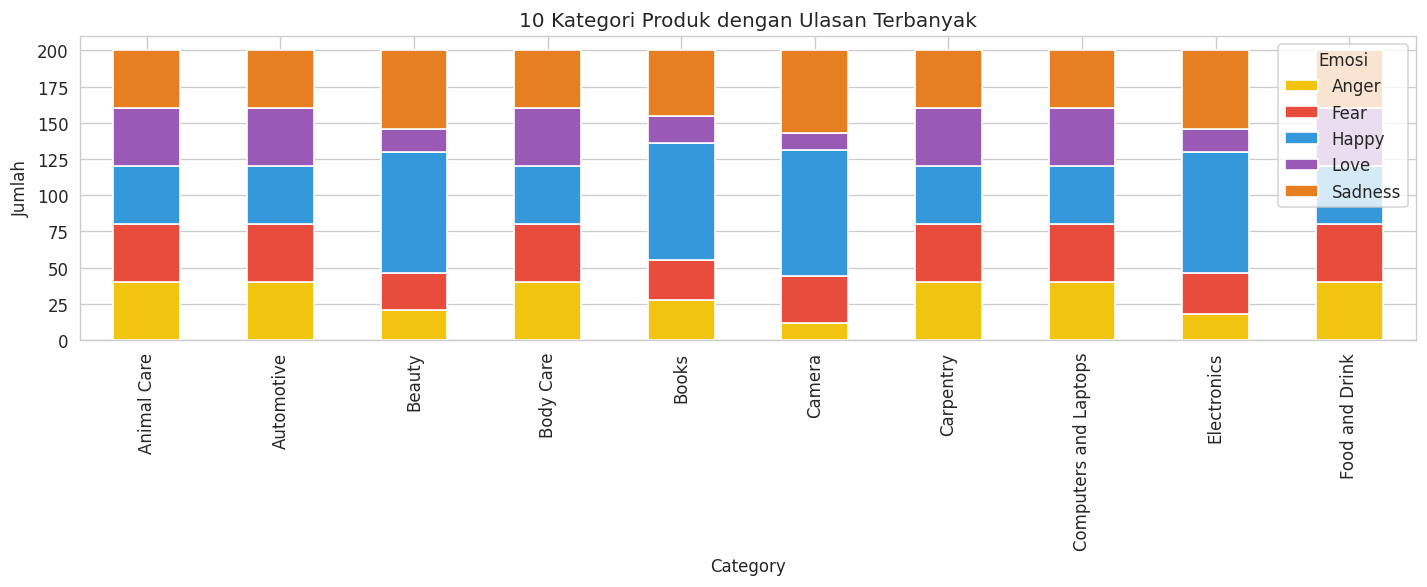

In [ ]:
kategori_emo = pd.crosstab(df['Category'], df['Emotion'])
kategori_emo['total'] = kategori_emo.sum(axis=1)
kategori_emo = kategori_emo.sort_values('total', ascending=False).head(10)
kategori_emo.drop('total', axis=1).plot(kind='bar', stacked=True, figsize=(12, 5), color=[colors[e] for e in emotion_order])
plt.title('10 Kategori Produk dengan Ulasan Terbanyak')
plt.ylabel('Jumlah')
plt.legend(title='Emosi')
plt.tight_layout()
plt.show()

## 8. Ringkasan untuk Laporan

In [ ]:
print("=== RINGKASAN ===")
print(f"Total ulasan: {len(df)}")
print(f"\n[Distribusi Emosi]")
dist = df['Emotion'].value_counts()
for emo in emotion_order:
    pct = dist[emo] / len(df) * 100
    print(f"  {emo:10s}: {dist[emo]:5d} ({pct:5.1f}%)")

print(f"\n[Panjang Teks per Emosi - Rata-rata]")
for emo in emotion_order:
    subset = df[df['Emotion'] == emo]['review_length']
    print(f"  {emo:10s}: {subset.mean():5.1f} karakter ({df[df['Emotion']==emo]['word_count'].mean():.1f} kata)")

print(f"\n[Rating per Emosi - Rata-rata]")
for emo in emotion_order:
    mean_rating = df[df['Emotion'] == emo]['Customer Rating'].mean()
    print(f"  {emo:10s}: {mean_rating:.2f}")

print(f"\n[Sentimen vs Emosi]")
ct = pd.crosstab(df['Emotion'], df['Sentiment'])
print(ct)

print(f"\n[Missing Values]")
null_cols = df.isnull().sum()
print(null_cols[null_cols > 0] if any(null_cols > 0) else "Tidak ada missing values")

=== RINGKASAN ===
Total ulasan: 5400

[Distribusi Emosi]
  Happy     :  1770 ( 32.8%)
  Love      :   809 ( 15.0%)
  Sadness   :  1202 ( 22.3%)
  Fear      :   920 ( 17.0%)
  Anger     :   699 ( 12.9%)

[Panjang Teks per Emosi - Rata-rata]
  Happy     :  84.8 karakter (12.5 kata)
  Love      :  96.3 karakter (14.1 kata)
  Sadness   : 106.6 karakter (17.1 kata)
  Fear      : 137.3 karakter (22.0 kata)
  Anger     : 111.8 karakter (18.0 kata)

[Rating per Emosi - Rata-rata]
  Happy     : 4.74
  Love      : 4.96
  Sadness   : 1.67
  Fear      : 1.51
  Anger     : 1.26

[Sentimen vs Emosi]
Sentiment  Negative  Positive
Emotion                      
Anger           699         0
Fear            920         0
Happy             0      1770
Love              0       809
Sadness        1202         0

[Missing Values]
Tidak ada missing values
